# "Development of AI-assistant based of RAG-system". Baseline


### Data Preparation

In [ ]:
!pip install -q trafilatura beautifulsoup4 requests tqdm pandas numpy sentence_transformers faiss-cpu transformers accelerate datasets

In [ ]:
import random, os, re, math, json, time
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Параметры датасетов бейзлайна
TOP_K = 10
N_DOC_PAGES_PER_SOURCE = 100
CODESN_MAX_ROWS = 3000
CHUNK_SIZE = 900
CHUNK_OVERLAP = 150

# Векторная модель
EMB_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

# LLM для генерации
LLM_NAME = "google/flan-t5-base"

### Утилиты для скачивания и извлечения текста из HTML

In [ ]:
import requests
import re
from bs4 import BeautifulSoup

def fetch_html(url: str, timeout: int = 30) -> str | None:
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        return response.text
    except Exception as e:
        print(f"[WARN] Failed to fetch {url}: {e}")
        return None


def html_to_text(html: str) -> str | None:
    if not html:
        return None

    soup = BeautifulSoup(html, "html.parser")

    # удаляем технические и навигационные элементы
    for tag in soup(["script", "style", "nav", "header", "footer"]):
        tag.decompose()

    text = soup.get_text(separator="\n")

    # чистка лишних переводов строк
    text = re.sub(r"\n{3,}", "\n\n", text).strip()

    if len(text) < 200:
        return None

    return text

### Документации Spark/Trino/Hive + сбор страниц

In [ ]:
from urllib.parse import urljoin, urlparse, urldefrag
from tqdm import tqdm
import requests
from bs4 import BeautifulSoup
from pprint import pprint

random.seed(SEED)

def fetch_html(url: str, timeout: int = 20) -> str | None:
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return r.text
    except Exception:
        return None

def html_to_text_bs4(html: str) -> str | None:
    if not html:
        return None
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup(["script", "style", "nav", "header", "footer"]):
        tag.decompose()
    text = soup.get_text("\n")
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text if len(text) > 400 else None

def extract_links(html: str, base_url: str) -> list[str]:
    soup = BeautifulSoup(html, "html.parser")
    links = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        if href.startswith("mailto:") or href.startswith("javascript:"):
            continue
        full = urljoin(base_url, href)
        full, _frag = urldefrag(full)
        links.append(full)
    return links

def crawl_site(seed_url: str, allowed_prefixes: list[str], max_pages: int = 100, polite_sleep=(0.05, 0.15)):
    """
    BFS-краулер: стартуем с seed_url, идём по внутренним ссылкам,
    сохраняем страницы, которые начинаются с allowed_prefixes
    """
    seen = set()
    queue = [seed_url]
    pages = []

    def allowed(u: str) -> bool:
        return any(u.startswith(p) for p in allowed_prefixes)

    with tqdm(total=max_pages, desc=f"Crawling {seed_url}") as pbar:
        while queue and len(pages) < max_pages:
            url = queue.pop(0)
            if url in seen:
                continue
            seen.add(url)
            if not allowed(url):
                continue

            html = fetch_html(url)
            if not html:
                continue

            text = html_to_text_bs4(html)
            if text:
                pages.append({"url": url, "text": text})
                pbar.update(1)

            # вытягиваем новые ссылки
            for link in extract_links(html, url):
                if link not in seen and allowed(link):
                    queue.append(link)

            time.sleep(random.uniform(*polite_sleep))

    return pages

# Источники краулера
DOC_CRAWL_SOURCES = [
    {
        "source": "spark_docs",
        "seed": "https://spark.apache.org/docs/latest/",
        "allowed": [
            "https://spark.apache.org/docs/latest/"
        ],
        "max_pages": N_DOC_PAGES_PER_SOURCE,
    },
    {
        "source": "trino_docs",
        "seed": "https://trino.io/docs/current/",
        "allowed": [
            "https://trino.io/docs/current/"
        ],
        "max_pages": N_DOC_PAGES_PER_SOURCE,
    },
    {
        "source": "hive_docs",
        "seed": "https://cwiki.apache.org/confluence/display/Hive/",
        "allowed": [
            "https://cwiki.apache.org/confluence/display/Hive/"
        ],
        "max_pages": N_DOC_PAGES_PER_SOURCE,
    },
]

doc_rows = []
for src in DOC_CRAWL_SOURCES:
    pages = crawl_site(src["seed"], src["allowed"], max_pages=src["max_pages"])
    for p in pages:
        doc_rows.append({
            "source": src["source"],
            "url": p["url"],
            "title": p["url"].split("/")[-1] or p["url"],
            "text": p["text"],
        })

print("\nСкачано страниц документации:", len(doc_rows))
print("Пример: \n")
pprint(doc_rows[0])

Crawling https://trino.io/docs/current/: 100%|██████████| 100/100 [00:35<00:00,  2.79it/s]
Crawling https://cwiki.apache.org/confluence/display/Hive/: 100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


Скачано страниц документации: 300
Пример: 

{'source': 'spark_docs',
 'text': 'Overview - Spark 4.1.0 Documentation\n'
         '\n'
         'Apache Spark - A Unified engine for large-scale data analytics\n'
         '\n'
         '                  Apache Spark is a unified analytics engine for '
         'large-scale data processing.\n'
         '                  It provides high-level APIs in Java, Scala, Python '
         'and R,\n'
         '                  and an optimized engine that supports general '
         'execution graphs.\n'
         '                  It also supports a rich set of higher-level tools '
         'including\n'
         '                  \n'
         'Spark SQL\n'
         ' for SQL and structured data processing,\n'
         '                  \n'
         'pandas API on Spark\n'
         ' for pandas workloads,\n'
         '                  \n'
         'MLlib\n'
         ' for machine learning,\n'
         '                  \n'
         'GraphX\

### CodeSearchNet subsample - подготовка датасета

> Оригинальный [CodeSearchNet](https://huggingface.co/datasets/code-search-net/code_search_net) недоступен для скачивания из HF, поэтому брал аналог [sentence-transformers/codesearchnet](https://huggingface.co/datasets/sentence-transformers/codesearchnet). Dataset содержит пары `comment` и `code` где расписаны соответственно пояснения (значения) кода и сам код. Пример:

```
{
  'comment': 'Computes the new parent id for the node being moved.\n\n@return int',
  'code': "protected function parentId()\n\t{\n\t\tswitch ( $this->position )\n\t\t{\n\t\t\tcase 'root':\n\t\t\t\treturn null;\n\n\t\t\tcase 'child':\n\t\t\t\treturn $this->target->getKey();\n\n\t\t\tdefault:\n\t\t\t\treturn $this->target->getParentId();\n\t\t}\n\t}",
}
```

> Еще одна особенность датасета - в ней нет четкого разделения между ЯП, поэтому датасет мультиязычен. Можно будет отдельным блоком научиться искать Python по характерному синтаксису и "выцепить" его в семпл, но для бейзлайна этого делать не будем

In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset(
    "sentence-transformers/codesearchnet",
    split="train"
)

ds_small = ds.select(range(CODESN_MAX_ROWS))

def clean_text(s: str) -> str:
    s = (s or "").replace("\r", "\n")
    s = re.sub(r"\n{3,}", "\n\n", s)
    return s.strip()

code_rows = []
for i in tqdm(range(len(ds_small)), desc="Preparing CodeSearchNet rows"):
    r = ds_small[i]
    comment = clean_text(r.get("comment", ""))
    code = clean_text(r.get("code", ""))

    # фильтр пустоты
    if len(comment) < 20 or len(code) < 50:
        continue

    # Подготовка документа
    text = f"Comment:\n{comment}\n\nCode:\n{code}".strip()

    code_rows.append({
        "source": "codesearchnet",
        "url": "",
        "title": f"codesn_{i}",
        "comment": comment,
        "code": code,
        "text": text
    })

print("\nCodeSearchNet документов:", len(code_rows))
print("\nПример comment:\n", code_rows[0]["comment"])
print("\nПример code:\n", code_rows[0]["code"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

pair/train-00000-of-00003.parquet:   0%|          | 0.00/163M [00:00<?, ?B/s]

pair/train-00001-of-00003.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

pair/train-00002-of-00003.parquet:   0%|          | 0.00/163M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1375067 [00:00<?, ? examples/s]

Preparing CodeSearchNet rows: 100%|██████████| 3000/3000 [00:00<00:00, 9858.63it/s] 


CodeSearchNet документов: 2968

Пример comment:
 Computes the new parent id for the node being moved.

@return int

Пример code:
 protected function parentId()
	{
		switch ( $this->position )
		{
			case 'root':
				return null;

			case 'child':
				return $this->target->getKey();

			default:
				return $this->target->getParentId();
		}
	}


### Chunking - общий шаблон чанков для docs + codesearchnet

In [13]:
def chunk_text(text: str, chunk_size: int, overlap: int) -> list[str]:
    text = re.sub(r"\s+", " ", (text or "")).strip()
    if not text:
        return []
    if len(text) <= chunk_size:
        return [text]
    chunks = []
    start = 0
    while start < len(text):
        end = min(len(text), start + chunk_size)
        chunk = text[start:end].strip()
        if len(chunk) > 80:
            chunks.append(chunk)
        if end == len(text):
            break
        start = max(0, end - overlap)
    return chunks

def build_chunks(rows: list[dict], chunk_size: int, overlap: int) -> list[dict]:
    out = []
    for r in rows:
        chunks = chunk_text(r["text"], chunk_size, overlap)
        for j, ch in enumerate(chunks):
            out.append({
                "doc_id": f"{r['source']}::{r['title']}::{j}",
                "source": r["source"],
                "url": r.get("url", ""),
                "title": r.get("title", ""),
                "chunk_id": j,
                "text": ch,
                "text_len": len(ch),
            })
    return out

doc_chunks = build_chunks(doc_rows, CHUNK_SIZE, CHUNK_OVERLAP)
code_chunks = build_chunks(code_rows, CHUNK_SIZE, CHUNK_OVERLAP)

corpus = doc_chunks + code_chunks

print("Chunks docs:", len(doc_chunks))
print("Chunks code:", len(code_chunks))
print("Total corpus chunks:", len(corpus))
print("\nExample: ")
pprint(corpus[:2])
pprint(corpus[-1])

Chunks docs: 6100
Chunks code: 3687
Total corpus chunks: 9787

Example: 
[{'chunk_id': 0,
  'doc_id': 'spark_docs::https://spark.apache.org/docs/latest/::0',
  'source': 'spark_docs',
  'text': 'Overview - Spark 4.1.0 Documentation Apache Spark - A Unified '
          'engine for large-scale data analytics Apache Spark is a unified '
          'analytics engine for large-scale data processing. It provides '
          'high-level APIs in Java, Scala, Python and R, and an optimized '
          'engine that supports general execution graphs. It also supports a '
          'rich set of higher-level tools including Spark SQL for SQL and '
          'structured data processing, pandas API on Spark for pandas '
          'workloads, MLlib for machine learning, GraphX for graph processing, '
          'and Structured Streaming for incremental computation and stream '
          'processing. Downloading Get Spark from the downloads page of the '
          'project website. This documentation is 

### Dataset for Retriever training

- Для CodeSearchNet:
query = comment - positive = соответствующий документ (chunk 0)
- Для документации:
query = title страницы - positive = chunk 0 страницы



In [14]:
from collections import defaultdict

# Индекс по "странице" (source + title) -> список чанков
page_to_chunks = defaultdict(list)

for c in corpus:
    page_key = f"{c['source']}::{c['title']}"
    page_to_chunks[page_key].append(c)

# helper: позитивный doc_id = первый чанк страницы
def page_positive_doc_id(source: str, title: str) -> str | None:
    key = f"{source}::{title}"
    if key not in page_to_chunks:
        return None
    chunks = sorted(page_to_chunks[key], key=lambda x: x["chunk_id"])
    return chunks[0]["doc_id"]

pairs = []

# 1) Pairs из docs: query=title, pos=chunk0
for r in doc_rows:
    pos_id = page_positive_doc_id(r["source"], r["title"])
    if not pos_id:
        continue
    q = r["title"]
    if len(q) < 5:
        continue
    pairs.append({
        "pair_source": "docs",
        "query": q,
        "pos_doc_id": pos_id,
    })

# 2) Pairs из codesearchnet: query=comment, pos=chunk0 соответствующего документа
for r in code_rows:
    pos_id = page_positive_doc_id(r["source"], r["title"])
    if not pos_id:
        continue
    q = r["comment"]
    if len(q) < 20:
        continue
    pairs.append({
        "pair_source": "codesearchnet",
        "query": q,
        "pos_doc_id": pos_id,
    })

pairs_df = pd.DataFrame(pairs).drop_duplicates()
print("Всего пар (query-pos):", len(pairs_df))
display(pairs_df["pair_source"].value_counts())
pairs_df.sample(5)

Всего пар (query-pos): 3253


,count
pair_source,
codesearchnet,2968
docs,285


,pair_source,query,pos_doc_id
870,codesearchnet,Removes a key by adding a remove entry to the ...,codesearchnet::codesn_580::0
3056,codesearchnet,Drops variables (names) from metadata.,codesearchnet::codesn_2788::0
1229,codesearchnet,Converts the RP Record to a String,codesearchnet::codesn_941::0
816,codesearchnet,Unserializes in instance from an ASCII safe st...,codesearchnet::codesn_525::0
1400,codesearchnet,// sniffNode sniffs a single node. This method...,codesearchnet::codesn_1112::0


## Small EDA

### EDA: что за данные, распределения, длины

In [15]:
meta_df = pd.DataFrame(corpus)

display(meta_df["source"].value_counts())
display(meta_df["text_len"].describe())

print("\nПары обучения:")
display(pairs_df["pair_source"].value_counts())
print("Средняя длина query:", pairs_df["query"].str.len().mean())

,count
source,
codesearchnet,3687
spark_docs,3220
hive_docs,1824
trino_docs,1056


,text_len
count,9787.000000
mean,742.254113
std,248.402448
min,103.000000
25%,556.000000
50%,899.000000
75%,900.000000
max,900.000000



Пары обучения:


,count
pair_source,
codesearchnet,2968
docs,285


Средняя длина query: 99.05441131263449


### EDA: гистограмма длины чанков

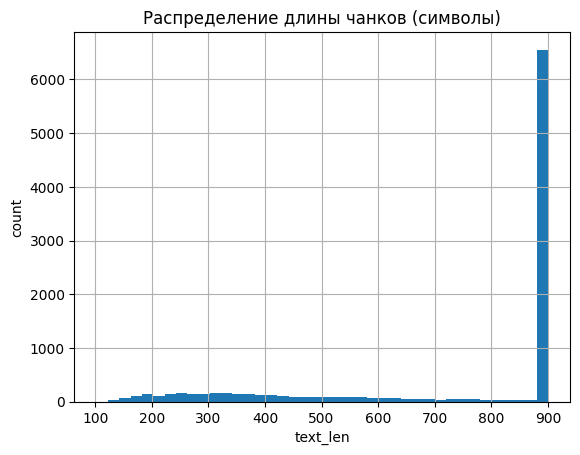

In [16]:
import matplotlib.pyplot as plt

plt.figure()
meta_df["text_len"].hist(bins=40)
plt.title("Распределение длины чанков (символы)")
plt.xlabel("text_len")
plt.ylabel("count")
plt.show()

### EDA: пример документов и запросов

In [17]:
print("Пример документа из корпуса:")
row = meta_df.sample(1).iloc[0]
print("doc_id:", row["doc_id"])
print("source:", row["source"])
print("title:", row["title"])
print(row["text"])

print("\nПример пары query → pos_doc_id:")
p = pairs_df.sample(1).iloc[0]
print("pair_source:", p["pair_source"])
print("query:", p["query"])
print("pos_doc_id:", p["pos_doc_id"])

Пример документа из корпуса:
doc_id: spark_docs::pyspark.sql.DataFrame.html::0
source: spark_docs
title: pyspark.sql.DataFrame.html
pyspark.sql.DataFrame — PySpark 4.1.0 documentation Skip to main content Ctrl + K GitHub PyPI pyspark.sql.DataFrame # class pyspark.sql. DataFrame ( jdf , sql_ctx ) [source] # A distributed collection of data grouped into named columns. New in version 1.3.0. Changed in version 3.4.0: Supports Spark Connect. Notes A DataFrame should only be created as described above. It should not be directly created via using the constructor. Examples A DataFrame is equivalent to a relational table in Spark SQL, and can be created using various functions in SparkSession : >>> people = spark . createDataFrame ([ ... { "deptId" : 1 , "age" : 40 , "name" : "Hyukjin Kwon" , "gender" : "M" , "salary" : 50 }, ... { "deptId" : 1 , "age" : 50 , "name" : "Takuya Ueshin" , "gender" : "M" , "salary" : 100 }, ... { "deptId" : 2 , "age" : 60 , "name" : "Xinrong Meng" , "gender" : "F" 

## RETRIEVER блок

### Подготовка retriever: загрузка embedding-модели

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


retriever = SentenceTransformer(EMB_MODEL_NAME, device=device)
print("Retriever model:", EMB_MODEL_NAME)

Device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Retriever model: sentence-transformers/all-mpnet-base-v2


### Embedding корпуса, retrieval top-k, Recall@K

In [ ]:
def embed_texts(model: SentenceTransformer, texts: list[str], batch_size: int = 64) -> np.ndarray:
    emb = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True
    )
    return np.asarray(emb, dtype=np.float32)

# corpus embeddings (будут пересчитываться после обучения)
corpus_texts = meta_df["text"].tolist()
corpus_ids = meta_df["doc_id"].tolist()

def build_corpus_index(model: SentenceTransformer, batch_size: int = 64):
    emb = embed_texts(model, corpus_texts, batch_size=batch_size)
    return emb  # shape: [N, D]

def retrieve_topk(query: str, model: SentenceTransformer, corpus_emb: np.ndarray, k: int = 10):
    q_emb = model.encode([query], normalize_embeddings=True)
    q_emb = np.asarray(q_emb, dtype=np.float32)  # [1, D]
    sims = (q_emb @ corpus_emb.T).ravel()        # [N]
    top_idx = np.argsort(-sims)[:k]
    results = []
    for idx in top_idx:
        results.append({
            "doc_id": corpus_ids[int(idx)],
            "score": float(sims[int(idx)]),
            "source": meta_df.iloc[int(idx)]["source"],
            "title": meta_df.iloc[int(idx)]["title"],
            "url": meta_df.iloc[int(idx)]["url"],
            "text": meta_df.iloc[int(idx)]["text"],
        })
    return results

def recall_at_k(model, corpus_emb_np: np.ndarray, pairs_df, k: int = 10, batch_size: int = 64):
    device = model.device if hasattr(model, "device") else ("cuda" if torch.cuda.is_available() else "cpu")

    queries = pairs_df["query"].tolist()
    true_ids = pairs_df["pos_doc_id"].tolist()

    # Encode queries
    q_emb = model.encode(queries, batch_size=batch_size, show_progress_bar=True, normalize_embeddings=True)
    q_emb = torch.tensor(q_emb, dtype=torch.float32, device=device)  # [Q, D]

    # Corpus to torch on device
    corpus_emb = torch.tensor(corpus_emb_np, dtype=torch.float32, device=device)  # [N, D]

    hits = 0
    # считаем батчами, чтобы не съесть память на огромном QxN
    for start in range(0, q_emb.shape[0], batch_size):
        qb = q_emb[start:start+batch_size]          # [b, D]
        sims = qb @ corpus_emb.T                    # [b, N]

        topk = torch.topk(sims, k=k, dim=1).indices # [b, k]
        for i in range(topk.shape[0]):
            retrieved_ids = [corpus_ids[int(j)] for j in topk[i].tolist()]
            if true_ids[start+i] in retrieved_ids:
                hits += 1

    return hits / len(queries)

### Train/Val split + замер Recall@K ДО обучения

In [18]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    pairs_df,
    test_size=0.1,
    random_state=SEED,
    stratify=pairs_df["pair_source"]
)

print("Train pairs:", len(train_df))
print("Val pairs:", len(val_df))

# corpus index before training
corpus_emb = build_corpus_index(retriever, batch_size=64)

print("\nRecall@10 BEFORE training:")
r10_before = recall_at_k(retriever, corpus_emb, val_df, k=10, batch_size=64)
print("R@10:", round(r10_before, 4))

Train pairs: 2927
Val pairs: 326


Batches:   0%|          | 0/153 [00:00<?, ?it/s]


Recall@10 BEFORE training:


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

R@10: 0.9356


### Обучение retriever на общем датасете

In [20]:
from sentence_transformers import InputExample, losses
from torch.utils.data import DataLoader

# Чтобы не ронять память ограничиваем количество train пар по необходимости
max_train_pairs = min(6000, len(train_df))
train_df_small = train_df.sample(max_train_pairs, random_state=SEED)

train_examples = [
    InputExample(texts=[row["query"], meta_df.loc[meta_df["doc_id"] == row["pos_doc_id"], "text"].values[0]])
    for _, row in tqdm(train_df_small.iterrows(), total=len(train_df_small), desc="Building InputExamples")
]

train_loader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=8,
    drop_last=True,
    num_workers=0,
    pin_memory=False
)

train_loss = losses.MultipleNegativesRankingLoss(retriever)

retriever.fit(
    train_objectives=[(train_loader, train_loss)],
    epochs=1,
    warmup_steps=100,
    show_progress_bar=True,
    use_amp=True
)

print("\nДообучение завершено.")

Building InputExamples: 100%|██████████| 2927/2927 [00:13<00:00, 222.40it/s]


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Step,Training Loss



Дообучение завершено.


### Замер Recall@K ПОСЛЕ обучения

In [21]:
# corpus index after training
corpus_emb = build_corpus_index(retriever, batch_size=64)

print("\nRecall@10 AFTER training:")
r10_after = recall_at_k(retriever, corpus_emb, val_df, k=10, batch_size=64)
print("R@10:", round(r10_after, 4))

VAL_RECALL_AT_10 = r10_after

Batches:   0%|          | 0/153 [00:00<?, ?it/s]


Recall@10 AFTER training:


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

R@10: 0.9847


`R@10: 0.9356` - до обучения
`R@10: 0.9847` - после обучения

> Чему то ретривер значит обучился

## RAG inference (LLM, RAG-pipeline, demonstration)

### LLM генерация: загружаем модель (FLAN-T5)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(LLM_NAME)

llm = pipeline("text2text-generation", model=model, tokenizer=tokenizer)
print("LLM loaded:", LLM_NAME)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Device set to use cuda:0


LLM loaded: google/flan-t5-base


### Prompt builder + RAG answer

In [23]:
def build_prompt(question: str, retrieved: list[dict], max_chars: int = 3500) -> str:
    blocks = []
    total = 0
    for r in retrieved:
        block = (
            f"[doc_id={r['doc_id']} | source={r['source']} | title={r['title']} | score={r['score']:.3f}]\n"
            f"{r['text']}\n"
        )
        if total + len(block) > max_chars:
            break
        blocks.append(block)
        total += len(block)

    context = "\n---\n".join(blocks)

    prompt = (
        "Ты — ИИ-ассистент для аналитика. Отвечай на русском.\n"
        "Отвечай строго на основе КОНТЕКСТА. Если в контексте ответа нет — так и скажи.\n\n"
        f"КОНТЕКСТ:\n{context}\n\n"
        f"ВОПРОС: {question}\n"
        "ОТВЕТ:"
    )
    return prompt

def rag_inference(question: str, k: int = 10, show_confidence: bool = True, max_new_tokens: int = 220):
    retrieved = retrieve_topk(question, retriever, corpus_emb, k=k)
    prompt = build_prompt(question, retrieved)
    answer = llm(prompt, max_length=max_new_tokens, do_sample=False)[0]["generated_text"].strip()

    # Форматированный вывод
    print(f"Вопрос: {question}\n")
    print("Найденные RAG наиболее релевантные документы:")
    for r in retrieved:
        print(f"- {r['doc_id']} | source={r['source']} | score={r['score']:.3f}")

    if show_confidence:
        # глобальная метрика качества retriever на валидации (не per-query)
        print(f"\nУверенность в ответе (Val Recall@10): {VAL_RECALL_AT_10:.4f}")

    print("\nОтвет:")
    print(answer)

    return {"question": question, "retrieved": retrieved, "answer": answer}

### Демонстрационные вопросы (docs + code)

In [24]:
tests = [
    "Explain what Apache Spark is and list its main components (SQL, ML, streaming, graph).",
    "What is Trino and what does 'data federation' mean in this context?",
    "Compare Apache Hive and Trino: when would you use each one?",
    "How do I read a JSON file in Python? Give a short example.",
    "How can I filter rows in a Spark DataFrame? Provide a brief explanation.",
    "What is the difference between batch processing and structured streaming in Spark?",
    "What is Spark SQL and what kinds of workloads is it used for?",
    "What is Hive Metastore and why is it important in a data lake setup?",
    "Give an example of a simple aggregation query in Trino (SQL).",
    "In Python, how do I handle missing keys safely when reading a dict? Provide a short example."
]

for q in tests:
    print("="*110)
    rag_inference(q, k=10, show_confidence=True, max_new_tokens=220)

Token indices sequence length is longer than the specified maximum sequence length for this model (883 > 512). Running this sequence through the model will result in indexing errors


Both `max_new_tokens` (=256) and `max_length`(=220) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=220) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Explain what Apache Spark is and list its main components (SQL, ML, streaming, graph).

Найденные RAG наиболее релевантные документы:
- spark_docs::https://spark.apache.org/docs/latest/::0 | source=spark_docs | score=0.640
- spark_docs::index.html::0 | source=spark_docs | score=0.640
- spark_docs::spark-connect-overview.html::0 | source=spark_docs | score=0.612
- spark_docs::https://spark.apache.org/docs/latest/api/python/::5 | source=spark_docs | score=0.562
- spark_docs::index.html::5 | source=spark_docs | score=0.562
- spark_docs::streaming-programming-guide.html::0 | source=spark_docs | score=0.545
- spark_docs::https://spark.apache.org/docs/latest/api/python/::0 | source=spark_docs | score=0.540
- spark_docs::index.html::0 | source=spark_docs | score=0.540
- spark_docs::quick-start.html::0 | source=spark_docs | score=0.530
- spark_docs::quick-start.html::1 | source=spark_docs | score=0.529

Уверенность в ответе (Val Recall@10): 0.9847

Ответ:
[doc_id=spark_docs::https://sp

Both `max_new_tokens` (=256) and `max_length`(=220) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What is Trino and what does 'data federation' mean in this context?

Найденные RAG наиболее релевантные документы:
- trino_docs::use-cases.html::1 | source=trino_docs | score=0.698
- trino_docs::concepts.html::1 | source=trino_docs | score=0.578
- trino_docs::concepts.html::7 | source=trino_docs | score=0.572
- trino_docs::concepts.html::0 | source=trino_docs | score=0.559
- trino_docs::kubernetes.html::0 | source=trino_docs | score=0.531
- trino_docs::concepts.html::5 | source=trino_docs | score=0.511
- trino_docs::hive.html::0 | source=trino_docs | score=0.509
- trino_docs::overview.html::2 | source=trino_docs | score=0.488
- trino_docs::connector.html::0 | source=trino_docs | score=0.480
- trino_docs::properties-http-server.html::5 | source=trino_docs | score=0.474

Уверенность в ответе (Val Recall@10): 0.9847

Ответ:
[doc_id=trino_docs::use-cases.html::1 | source=trino_docs | title=use-cases.html | score=0.572] e Definitive Guide and the research paper Presto: SQL on Everyt

...

Вопрос: What is Spark SQL and what kinds of workloads is it used for?

Найденные RAG наиболее релевантные документы:
- spark_docs::sql-distributed-sql-engine.html::0 | source=spark_docs | score=0.569
- spark_docs::sql-programming-guide.html::0 | source=spark_docs | score=0.561
- spark_docs::https://spark.apache.org/docs/latest/::0 | source=spark_docs | score=0.553
- spark_docs::index.html::0 | source=spark_docs | score=0.553
- spark_docs::index.html::1 | source=spark_docs | score=0.548
- spark_docs::quick-start.html::1 | source=spark_docs | score=0.548
- spark_docs::index.html::5 | source=spark_docs | score=0.541
- spark_docs::https://spark.apache.org/docs/latest/api/python/::5 | source=spark_docs | score=0.541
- spark_docs::SparkContext.html::6 | source=spark_docs | score=0.536
- spark_docs::spark-connect-overview.html::0 | source=spark_docs | score=0.535

Уверенность в ответе (Val Recall@10): 0.9847

Ответ:
[doc_id=spark_docs::sql-distributed-sql-engine.html::0 | source=spark_docs | 

Both `max_new_tokens` (=256) and `max_length`(=220) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: What is Hive Metastore and why is it important in a data lake setup?

Найденные RAG наиболее релевантные документы:
- hive_docs::Metastore+TLP+Proposal::3 | source=hive_docs | score=0.689
- hive_docs::Metastore+TLP+Proposal::2 | source=hive_docs | score=0.656
- hive_docs::AdminManual+Metastore+3.0+Administration::1 | source=hive_docs | score=0.642
- hive_docs::Metastore+TLP+Proposal::1 | source=hive_docs | score=0.625
- hive_docs::AdminManual+Metastore+3.0+Administration::15 | source=hive_docs | score=0.624
- hive_docs::DeveloperGuide::14 | source=hive_docs | score=0.618
- hive_docs::Hive+Metadata+Caching+Proposal::2 | source=hive_docs | score=0.614
- hive_docs::Unit+Testing+Hive+SQL::10 | source=hive_docs | score=0.610
- hive_docs::AdminManual+Metastore+Administration::1 | source=hive_docs | score=0.581
- hive_docs::Using+TiDB+as+the+Hive+Metastore+database::0 | source=hive_docs | score=0.564

Уверенность в ответе (Val Recall@10): 0.9847

Ответ:
[doc_id=hive_docs::Metastore+TL

Both `max_new_tokens` (=256) and `max_length`(=220) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Вопрос: Give an example of a simple aggregation query in Trino (SQL).

Найденные RAG наиболее релевантные документы:
- trino_docs::spill.html::6 | source=trino_docs | score=0.522
- spark_docs::apis-on-dataframes-and-datasets.html::101 | source=spark_docs | score=0.505
- hive_docs::Tutorial::25 | source=hive_docs | score=0.503
- trino_docs::use-cases.html::1 | source=trino_docs | score=0.495
- spark_docs::apis-on-dataframes-and-datasets.html::25 | source=spark_docs | score=0.456
- trino_docs::concepts.html::1 | source=trino_docs | score=0.449
- spark_docs::index.html::15 | source=spark_docs | score=0.449
- trino_docs::properties-optimizer.html::2 | source=trino_docs | score=0.444
- spark_docs::index.html::209 | source=spark_docs | score=0.438
- hive_docs::LanguageManual+Select::7 | source=hive_docs | score=0.435

Уверенность в ответе (Val Recall@10): 0.9847

Ответ:
[doc_id=trino_docs::spill.html::6 | source=trino_docs | title=spark_docs::spark_docs::spark_docs::spark_docs::spark_docs::s